# Практична робота №21
## Метод Монте-Карло: обчислення визначеного інтеграла
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів)  
**№ у журналі:** 26


In [1]:
import numpy as np

np.random.seed(6)

def mc_integrate_exp(n_points):
    u = np.random.uniform(0.0, 1.0, n_points)
    f_vals = np.exp(-u)
    return f_vals.mean()

n_sample = 1000
est_val = mc_integrate_exp(n_sample)
exact_val = 1.0 - np.exp(-1.0)
abs_err = abs(est_val - exact_val)

print(f"Оцінка інтеграла при N={n_sample}: {est_val:.5f}")
print(f"Аналітичне точне значення: {exact_val:.5f}")
print(f"Абсолютна похибка: {abs_err:.5f} (відносна: {abs_err / exact_val * 100:.2f}%)")


Оцінка інтеграла при N=1000: 0.62906
Аналітичне точне значення: 0.63212
Абсолютна похибка: 0.00306 (відносна: 0.48%)


   N   |   Оцінка   | Абсолютна похибка
--------------------------------------
   100 |  0.611754  |     0.020367
  1000 |  0.629062  |     0.003059
 10000 |  0.629046  |     0.003075
100000 |  0.633152  |     0.001031


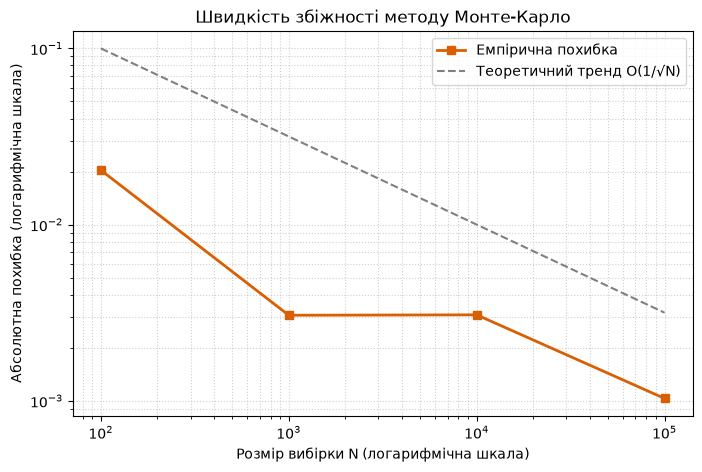

In [2]:
import matplotlib.pyplot as plt

sample_grid = [100, 1000, 10000, 100000]
mc_estimates = []
mc_errors = []

print("   N   |   Оцінка   | Абсолютна похибка")
print("-" * 38)
for n in sample_grid:
    np.random.seed(6)
    est = mc_integrate_exp(n)
    err = abs(est - exact_val)
    mc_estimates.append(est)
    mc_errors.append(err)
    print(f"{n:6d} |  {est:.6f}  |     {err:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(sample_grid, mc_errors, marker='s', color="#d95f02", lw=2, label="Емпірична похибка")
plt.plot(sample_grid, [1.0 / np.sqrt(n) for n in sample_grid], linestyle="--", color="gray", label="Теоретичний тренд O(1/√N)")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Розмір вибірки N (логарифмічна шкала)")
plt.ylabel("Абсолютна похибка (логарифмічна шкала)")
plt.title("Швидкість збіжності методу Монте-Карло")
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend()
plt.show()


### Теоретичні відповіді та обґрунтування

1. **Збіжність методу та Закон великих чисел:**  
   Оцінка інтеграла методом Монте-Карло заснована на поданні $\int_0^1 f(x) dx$ як математичного сподівання $\mathbb{E}[f(U)]$, де $U \sim \mathcal{U}(0, 1)$. За посиленим Законом великих чисел середнє арифметичне незалежних однаково розподілених величин майже напевно збігається до точного значення інтеграла: $\frac{1}{N} \sum_{i=1}^N f(U_i) \xrightarrow{a.s.} \int_0^1 f(x) dx$.

2. **Точність та Центральна гранична теорема:**  
   Відповідно до ЦГТ, розподіл випадкової похибки оцінки асимптотично наближається до нормального з нульовим середнім та стандартним відхиленням $\frac{\sigma_f}{\sqrt{N}}$. Звідси випливає фундаментальна швидкість збіжності $\mathcal{O}(1/\sqrt{N})$, яка не залежить від розмірності простору інтегрування. Для підвищення точності у 10 разів обсяг генерації $N$ необхідно збільшувати в 100 разів.

3. **Геометрична сутність вибіркового середнього:**  
   У методі вибіркового середнього ми апроксимуємо площу під кривою інтеграла середньою висотою випадкових ординат, помноженою на ширину інтервалу $[a, b]$, що є статистичним еквівалентом числового інтегрування прямокутниками на стохастичній сітці.

4. **Універсальність характеристик розсіювання:**  
   Статистичні формули дисперсії оцінки випливають із загальної теорії вибіркових оцінок параметрів випадкових величин і застосовуються аналогічно для будь-яких неперервних інтегровних функцій.
